PART A
Linear Least Squares:
  y = 0.9500x + 0.5900
  MSE = 0.061400
  R^2 = 0.967102

Cubic Polynomial Fit:
  coefficients = [ 0.04166667 -0.51071429  2.74761905 -1.06      ]
  MSE = 0.004829
  R^2 = 0.997413

Better fit by MSE: Cubic Polynomial
Better fit by R^2: Cubic Polynomial


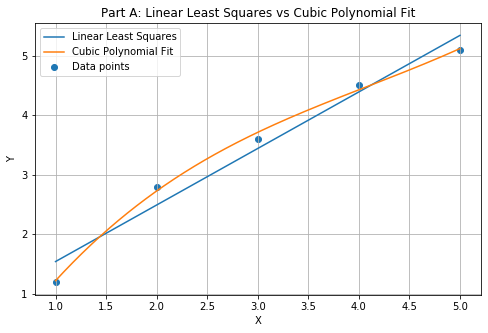


PART B
Randomized X: [2. 1. 4. 5. 3.]
Randomized Y: [5.1 4.5 1.2 3.6 2.8]
Degree 1: MSE = 1.216600, R^2 = 0.348157
Degree 2: MSE = 0.952457, R^2 = 0.489682
Degree 3: MSE = 0.000257, R^2 = 0.999862
Degree 4: MSE = 0.000000, R^2 = 1.000000


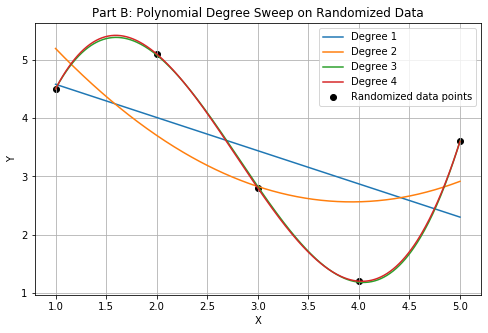


Part B comments:
- Degree 1 is the linear case and will usually underfit scattered/randomized data.
- Degree 2 and 3 may follow the data more closely.
- Degree 4 can exactly hit all 5 points, which often indicates overfitting on this tiny dataset.

PART C
Vandermonde Cubic Fit:
  coefficients = [ 0.04166667 -0.51071429  2.74761905 -1.06      ]
  MSE = 0.004829
  R^2 = 0.997413


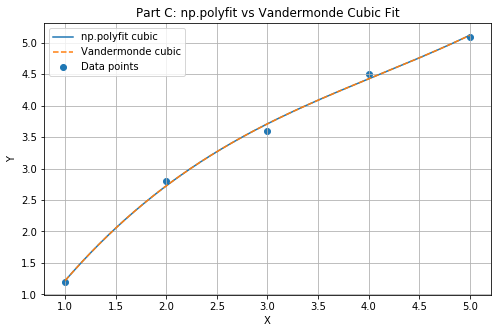

In [2]:
import numpy as np
import matplotlib.pyplot as plt


X = np.array([1, 2, 3, 4, 5], dtype=float)
Y = np.array([1.2, 2.8, 3.6, 4.5, 5.1], dtype=float)


x_plot = np.linspace(X.min(), X.max(), 400)


def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - ss_res / ss_tot



A_lin = np.vstack([X, np.ones(len(X))]).T
m_lin, c_lin = np.linalg.lstsq(A_lin, Y, rcond=None)[0]

y_lin = m_lin * X + c_lin
y_lin_plot = m_lin * x_plot + c_lin

mse_lin = mse(Y, y_lin)
r2_lin = r_squared(Y, y_lin)

deg_cubic = 3
coef_cubic = np.polyfit(X, Y, deg_cubic)
poly_cubic = np.poly1d(coef_cubic)

y_cubic = poly_cubic(X)
y_cubic_plot = poly_cubic(x_plot)

mse_cubic = mse(Y, y_cubic)
r2_cubic = r_squared(Y, y_cubic)

print("PART A")
print("Linear Least Squares:")
print(f"  y = {m_lin:.4f}x + {c_lin:.4f}")
print(f"  MSE = {mse_lin:.6f}")
print(f"  R^2 = {r2_lin:.6f}")

print("\nCubic Polynomial Fit:")
print(f"  coefficients = {coef_cubic}")
print(f"  MSE = {mse_cubic:.6f}")
print(f"  R^2 = {r2_cubic:.6f}")

if mse_lin < mse_cubic:
    print("\nBetter fit by MSE: Linear Least Squares")
else:
    print("\nBetter fit by MSE: Cubic Polynomial")

if r2_lin > r2_cubic:
    print("Better fit by R^2: Linear Least Squares")
else:
    print("Better fit by R^2: Cubic Polynomial")

plt.figure(figsize=(8, 5))
plt.scatter(X, Y, label="Data points")
plt.plot(x_plot, y_lin_plot, label="Linear Least Squares")
plt.plot(x_plot, y_cubic_plot, label="Cubic Polynomial Fit")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Part A: Linear Least Squares vs Cubic Polynomial Fit")
plt.grid(True)
plt.legend()
plt.show()


X_rand = np.random.permutation(X)
Y_rand = np.random.permutation(Y)

x_plot_rand = np.linspace(X_rand.min(), X_rand.max(), 400)

print("\n" + "="*60)
print("PART B")
print("Randomized X:", X_rand)
print("Randomized Y:", Y_rand)

degrees = [1, 2, 3, 4]

results = []

plt.figure(figsize=(8, 5))
plt.scatter(X_rand, Y_rand, color="black", label="Randomized data points")

for d in degrees:
    coef_d = np.polyfit(X_rand, Y_rand, d)
    poly_d = np.poly1d(coef_d)

    y_fit_d = poly_d(X_rand)
    y_plot_d = poly_d(x_plot_rand)

    mse_d = mse(Y_rand, y_fit_d)
    r2_d = r_squared(Y_rand, y_fit_d)

    results.append((d, mse_d, r2_d))
    plt.plot(x_plot_rand, y_plot_d, label=f"Degree {d}")

    print(f"Degree {d}: MSE = {mse_d:.6f}, R^2 = {r2_d:.6f}")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Part B: Polynomial Degree Sweep on Randomized Data")
plt.grid(True)
plt.legend()
plt.show()

print("\nPart B comments:")
print("- Degree 1 is the linear case and will usually underfit scattered/randomized data.")
print("- Degree 2 and 3 may follow the data more closely.")
print("- Degree 4 can exactly hit all 5 points, which often indicates overfitting on this tiny dataset.")


def vandermonde_fit(x, y, degree):

    V = np.vander(x, degree + 1, increasing=False)
    coeffs = np.linalg.lstsq(V, y, rcond=None)[0]
    return coeffs

def evaluate_polynomial(coeffs, x):
    return np.polyval(coeffs, x)

deg_vander = 3
coef_vander = vandermonde_fit(X, Y, deg_vander)

y_vander = evaluate_polynomial(coef_vander, X)
y_vander_plot = evaluate_polynomial(coef_vander, x_plot)

mse_vander = mse(Y, y_vander)
r2_vander = r_squared(Y, y_vander)

print("\n" + "="*60)
print("PART C")
print("Vandermonde Cubic Fit:")
print(f"  coefficients = {coef_vander}")
print(f"  MSE = {mse_vander:.6f}")
print(f"  R^2 = {r2_vander:.6f}")

plt.figure(figsize=(8, 5))
plt.scatter(X, Y, label="Data points")
plt.plot(x_plot, y_cubic_plot, label="np.polyfit cubic")
plt.plot(x_plot, y_vander_plot, "--", label="Vandermonde cubic")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Part C: np.polyfit vs Vandermonde Cubic Fit")
plt.grid(True)
plt.legend()
plt.show()

In [3]:
# AI USAGE DISCLOSURE:
# I used AI mostly to double check my syntax and make sure I was
# organizing the code correctly for comparing linear least squares, polynomial
# fitting, and the Vandermonde matrix approach. I also used it to confirm how to
# compute MSE and R-squared in Python. The overall method and concepts for least
# squares, polynomial fitting, and overfitting come from the course
# lecture slides.
#
# AI Tool Used: ChatGPT
# Prompt Used:
# "Check my Python approach for comparing linear least squares, polynomial fits,
# and a Vandermonde matrix polynomial fit, and computing MSE and R-squared."